In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows 기준. Mac은 'AppleGothic'으로 변경)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [11]:
print("데이터를 불러옵니다...")
episodes = pd.read_csv('data/raw/episodes.csv')
works = pd.read_csv('data/raw/works.csv')

raw_targets = []

for work_id, group in episodes.groupby('work_id'):
    group = group.sort_values('episode_number')
    paid_eps = group[group['access_type'] == 'PAID']
    free_eps = group[group['access_type'] == 'FREE']
    
    if paid_eps.empty or free_eps.empty: 
        continue
    
    # [과거 오류 방식]: 무조건 맨 마지막 무료 회차를 T 시점으로 설정
    t_episode = free_eps.iloc[-1] 
    t_plus_1 = paid_eps.iloc[0]
    
    if pd.isna(t_episode['view_count']) or t_episode['view_count'] == 0: 
        continue
    if pd.isna(t_plus_1['view_count']): 
        continue
        
    retention = t_plus_1['view_count'] / t_episode['view_count']
    raw_targets.append({'work_id': work_id, 'raw_retention': retention})
    
df_raw = pd.DataFrame(raw_targets)
print(f"추출된 전체 작품 수: {len(df_raw)}")
print(f"최대 유지율(아웃라이어): {df_raw['raw_retention'].max():.2f}")

데이터를 불러옵니다...
추출된 전체 작품 수: 20283
최대 유지율(아웃라이어): 23.16


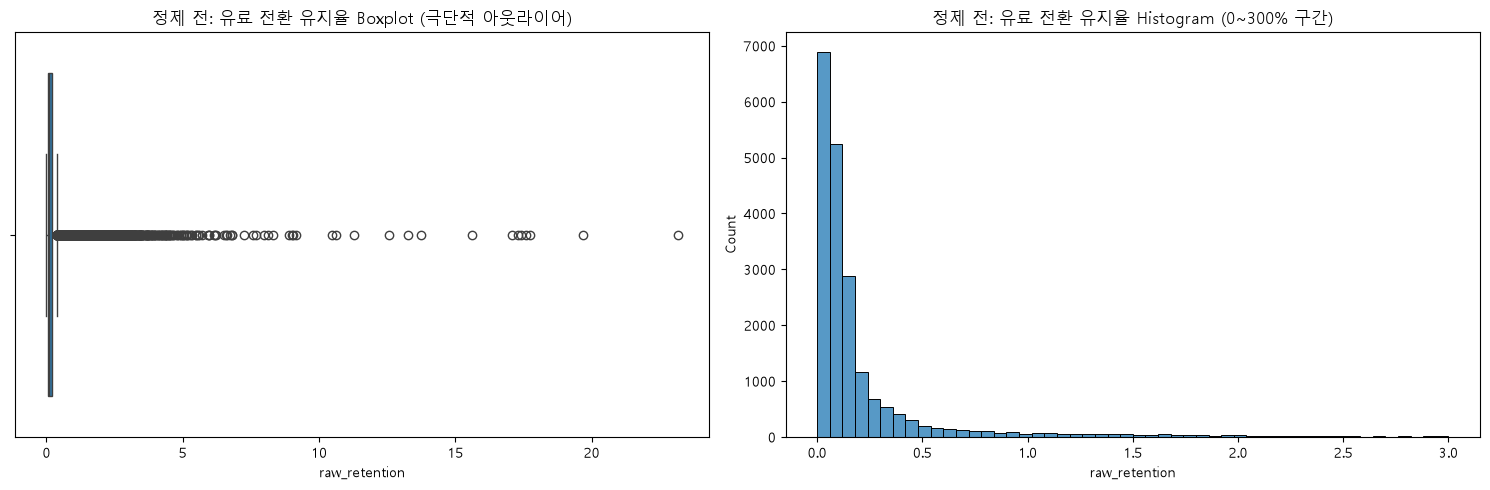

In [12]:
# 엄청난 꼬리를 가진 극단적 이상치가 존재하는지 시각화로 확인합니다.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot
sns.boxplot(x=df_raw['raw_retention'], ax=axes[0])
axes[0].set_title('정제 전: 유료 전환 유지율 Boxplot (극단적 아웃라이어)')

# Histogram (형태를 보기 위해 0~300% 구간만 확대)
sns.histplot(df_raw[df_raw['raw_retention'] <= 3.0]['raw_retention'], bins=50, ax=axes[1])
axes[1].set_title('정제 전: 유료 전환 유지율 Histogram (0~300% 구간)')

plt.tight_layout()
plt.show()

In [13]:
outlier_work = df_raw[df_raw['raw_retention'] > 20].iloc[0]
wid = outlier_work['work_id']

eps = episodes[episodes['work_id'] == wid].sort_values('episode_number')
free_eps = eps[eps['access_type'] == 'FREE']
paid_eps = eps[eps['access_type'] == 'PAID']

print(f"🚨 [이상치 원인 분석 - 작품번호 {wid}]")
print(f"- 무료 1화 조회수: {free_eps.iloc[0]['view_count']}")
print(f"- 첫 유료화 ({paid_eps.iloc[0]['episode_number']}화) 조회수: {paid_eps.iloc[0]['view_count']}")
print(f"-> ❌ 과거 로직이 잡은 가짜 마지막 무료화({free_eps.iloc[-1]['episode_number']}화) 조회수: {free_eps.iloc[-1]['view_count']}")
print("   (이유: 유료화 이후 한참 뒤에 올린 휴재/공지사항을 마지막 무료화로 착각함)")

🚨 [이상치 원인 분석 - 작품번호 518524.0]
- 무료 1화 조회수: 43150
- 첫 유료화 (24화) 조회수: 857
-> ❌ 과거 로직이 잡은 가짜 마지막 무료화(211화) 조회수: 37
   (이유: 유료화 이후 한참 뒤에 올린 휴재/공지사항을 마지막 무료화로 착각함)


In [14]:
dataset = []

for work_id, group in episodes.groupby('work_id'):
    group = group.sort_values('episode_number')
    paid_eps = group[group['access_type'] == 'PAID']
    free_eps = group[group['access_type'] == 'FREE']
    
    if paid_eps.empty or free_eps.empty: 
        continue
        
    first_paid_num = paid_eps.iloc[0]['episode_number']
    
    # 💡 [핵심 해결책]: 진짜 T 시점 찾기
    valid_free_eps = free_eps[free_eps['episode_number'] < first_paid_num]
    if valid_free_eps.empty: 
        continue
        
    t_episode = valid_free_eps.iloc[-1]
    t_plus_1 = paid_eps.iloc[0]
    
    if pd.isna(t_episode['view_count']) or t_episode['view_count'] == 0: 
        continue
        
    retention_rate = t_plus_1['view_count'] / t_episode['view_count']
    ep_1_view = valid_free_eps.iloc[0]['view_count']
    
    # 💡 [아웃라이어 제거]: 1화 조회수 100 미만 노이즈 & 이벤트성 300% 이상 제거
    if retention_rate > 3.0 or ep_1_view < 100:
        continue
        
    # --- 피처 생성 ---
    free_retention = t_episode['view_count'] / ep_1_view
    mean_view = valid_free_eps['view_count'].mean()
    mean_like = valid_free_eps['like_count'].mean()
    mean_comment = valid_free_eps['comment_count'].mean()
    
    if len(valid_free_eps) >= 5:
        recent_5 = valid_free_eps.iloc[-5:]
        momentum = (recent_5.iloc[-1]['view_count'] - recent_5.iloc[0]['view_count']) / recent_5.iloc[0]['view_count']
    else:
        momentum = 0
        
    dataset.append({
        'work_id': work_id,
        'free_chapter_count': len(valid_free_eps),
        'free_retention': free_retention,
        'like_to_view_ratio': mean_like / mean_view if mean_view > 0 else 0,
        'comment_to_view_ratio': mean_comment / mean_view if mean_view > 0 else 0,
        'momentum_last_5': momentum,
        'target_retention_rate': retention_rate
    })

df_clean = pd.DataFrame(dataset)
print(f"✅ 정제 완료! 학습 가능한 최종 데이터 수: {len(df_clean)}")

✅ 정제 완료! 학습 가능한 최종 데이터 수: 18260


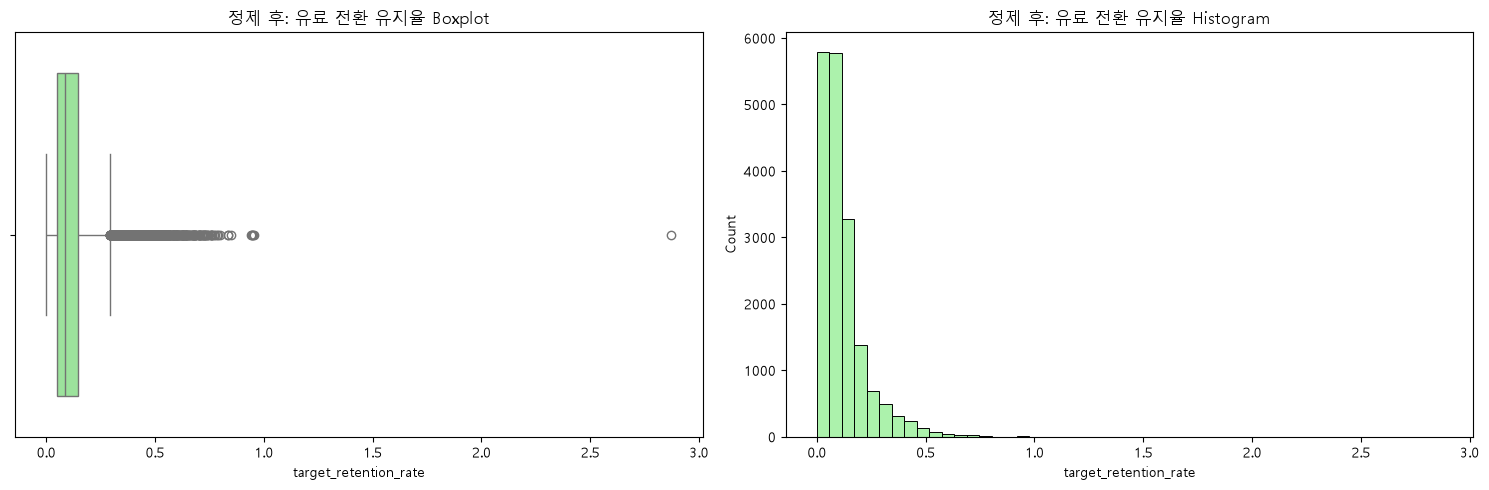

In [15]:
# 노이즈가 제거된 깔끔한 타깃 분포를 확인합니다.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x=df_clean['target_retention_rate'], ax=axes[0], color='lightgreen')
axes[0].set_title('정제 후: 유료 전환 유지율 Boxplot')

sns.histplot(df_clean['target_retention_rate'], bins=50, ax=axes[1], color='lightgreen')
axes[1].set_title('정제 후: 유료 전환 유지율 Histogram')

plt.tight_layout()
plt.show()

In [21]:
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from lightgbm import LGBMRegressor
import xgboost as xgb
import ast # JSON 파싱용

print("1. 피처(Feature)를 확장합니다...")

# works.csv에서 필요한 추가 피처 가져오기
works_features = works[['work_id', 'characters', 'genres_json', 'tags_json', 'chapter_count']].copy()
works_features['characters'] = pd.to_numeric(works_features['characters'], errors='coerce').fillna(0)

# 장르 데이터 파싱하여 원핫 인코딩 (판타지, 무협 등 주요 장르 여부)
def extract_first_genre(genre_str):
    try:
        genres = ast.literal_eval(genre_str)
        return genres[0] if len(genres) > 0 else '기타'
    except:
        return '기타'

works_features['main_genre'] = works_features['genres_json'].apply(extract_first_genre)
genre_dummies = pd.get_dummies(works_features['main_genre'], prefix='genre')
works_features = pd.concat([works_features, genre_dummies], axis=1)

# 태그 개수 피처 추가
def count_tags(tag_str):
    try:
        return len(ast.literal_eval(tag_str))
    except:
        return 0
works_features['tag_count'] = works_features['tags_json'].apply(count_tags)

# 💡 기존 정제된 데이터(df_clean)에 새로운 피처 병합
df_extended = df_clean.merge(works_features.drop(columns=['genres_json', 'tags_json', 'main_genre']), on='work_id', how='left')

# ---------------------------------------------------------

print("\n2. 이종 앙상블(Voting Ensemble) 모델 학습을 시작합니다...")

drop_cols = ['work_id', 'target_retention_rate']
if 'management_status' in df_extended.columns: drop_cols.append('management_status')
if 'predicted_retention' in df_extended.columns: drop_cols.append('predicted_retention')

X = df_extended.drop(columns=drop_cols, errors='ignore')
y = df_extended['target_retention_rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 개별 모델 정의 (LGBM 로그 끄기: verbose=-1)
xgb_model = xgb.XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42)
lgbm_model = LGBMRegressor(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42, verbose=-1)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42)

# Voting 앙상블 결합 및 학습
ensemble_model = VotingRegressor(estimators=[('xgb', xgb_model), ('lgbm', lgbm_model), ('rf', rf_model)])
ensemble_model.fit(X_train, y_train)

y_pred_ens = ensemble_model.predict(X_test)
mae_ens = mean_absolute_error(y_test, y_pred_ens)
rmse_ens = np.sqrt(mean_squared_error(y_test, y_pred_ens))

print(f"🎯 앙상블 MAE (평균 절대 오차): {mae_ens:.4f}")
print(f"🎯 앙상블 RMSE (평균 제곱근 오차): {rmse_ens:.4f}")

# 💡 [버그 수정]: VotingRegressor 내부에서 실제로 학습된 첫 번째 모델(XGBoost)을 꺼내서 사용
fitted_xgb = ensemble_model.estimators_[0]

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': fitted_xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\n[피처 중요도 (XGBoost 기준 Top 10)]")
display(feature_importance.head(10))

1. 피처(Feature)를 확장합니다...

2. 이종 앙상블(Voting Ensemble) 모델 학습을 시작합니다...
🎯 앙상블 MAE (평균 절대 오차): 0.0503
🎯 앙상블 RMSE (평균 제곱근 오차): 0.0777

[피처 중요도 (XGBoost 기준 Top 10)]


,feature,importance
1,free_retention,0.172415
4,momentum_last_5,0.134888
3,comment_to_view_ratio,0.127475
6,chapter_count,0.100239
16,genre_로맨스,0.084570
0,free_chapter_count,0.054912
35,tag_count,0.050912
2,like_to_view_ratio,0.044280
5,characters,0.038860
30,genre_판타지,0.033668


In [23]:
# 앙상블 모델을 사용하여 전체 데이터 예측
df_extended['predicted_retention'] = ensemble_model.predict(X)

def assign_risk_level(pred_rate):
    if pred_rate >= 0.30: return '🟢 안정 (대박 예상)'
    elif pred_rate >= 0.15: return '🟡 보통 (유지 관망)'
    else: return '🔴 위험 (급감 예상, 프로모션 필요)'

df_extended['management_status'] = df_extended['predicted_retention'].apply(assign_risk_level)

dashboard_df = df_extended[['work_id', 'predicted_retention', 'management_status']].merge(
    works[['work_id', 'title', 'author_name']], on='work_id', how='left'
)

# 퍼센트 포맷팅 (화면 출력용)
dashboard_df['예상 유지율(%)'] = (dashboard_df['predicted_retention'] * 100).round(1).astype(str) + '%'

# 💡 [버그 수정]: 문자열인 '예상 유지율(%)' 대신, 원본 숫자인 'predicted_retention' 기준으로 정렬!
final_view = dashboard_df.sort_values(by='predicted_retention', ascending=False)[
    ['work_id', 'title', 'author_name', '예상 유지율(%)', 'management_status']
]

print("\n[관리 대시보드 - 예상 유지율 상위 10개 작품]")
display(final_view.head(10))


[관리 대시보드 - 예상 유지율 상위 10개 작품]


,work_id,title,author_name,예상 유지율(%),management_status
10448,325345,마법의 신이 되다,마음글,147.0%,🟢 안정 (대박 예상)
11111,337046,살인사건 전담팀,유지,53.8%,🟢 안정 (대박 예상)
7993,260159,천정연분이라고 합니다,진소유,53.4%,🟢 안정 (대박 예상)
8032,261408,제비꽃의 심장,달비슬윤,51.7%,🟢 안정 (대박 예상)
11841,353707,"인생 2회차, 내 뜻대로 살겠습니다",페이즐,51.4%,🟢 안정 (대박 예상)
16382,468826,행림춘,좌작령령수,51.2%,🟢 안정 (대박 예상)
4429,136804,쪽빛 로맨스,모타,51.2%,🟢 안정 (대박 예상)
9311,294925,2000년 만화천재,차지우,49.9%,🟢 안정 (대박 예상)
16820,489734,후문신의,구천몽,49.1%,🟢 안정 (대박 예상)
8691,282475,최애를 살리려다 여주가 되어 버렸다,서재의,49.0%,🟢 안정 (대박 예상)


In [ ]:
import pandas as pd
import numpy as np

print("데이터를 불러오고 신규 피처와 듀얼 타깃을 추출합니다...")
episodes = pd.read_csv('data/raw/episodes.csv')
works = pd.read_csv('data/raw/works.csv')

# 시간 계산을 위해 datetime 타입으로 변환
episodes['published_at'] = pd.to_datetime(episodes['published_at'], errors='coerce')

dataset = []

for work_id, group in episodes.groupby('work_id'):
    group = group.sort_values('episode_number')
    paid_eps = group[group['access_type'] == 'PAID']
    free_eps = group[group['access_type'] == 'FREE']
    
    if paid_eps.empty or free_eps.empty: continue
        
    first_paid_num = paid_eps.iloc[0]['episode_number']
    valid_free_eps = free_eps[free_eps['episode_number'] < first_paid_num]
    
    if valid_free_eps.empty: continue
        
    t_episode = valid_free_eps.iloc[-1]
    t_plus_1 = paid_eps.iloc[0]
    
    if pd.isna(t_episode['view_count']) or t_episode['view_count'] == 0: continue
        
    ep_1_view = valid_free_eps.iloc[0]['view_count']
    if ep_1_view < 100: continue # 1화 조회수 100 미만 노이즈 제거
        
    # ==========================================
    # 타깃 1 & 2 정의 (듀얼 타깃)
    # ==========================================
    # 1. 초기 유료 전환율 (첫 유료화 / 마지막 무료화)
    initial_retention = t_plus_1['view_count'] / t_episode['view_count']
    if initial_retention > 3.0: continue # 이벤트성 아웃라이어 제거

    # 2. 미래 전망치 (유료 10화 조회수 / 유료 1화 조회수) -> 진짜 충성 독자 유지율
    if len(paid_eps) >= 10:
        future_retention = paid_eps.iloc[9]['view_count'] / paid_eps.iloc[0]['view_count']
    else:
        # 10화까지 안 나왔다면 현재 최신 유료 회차 기준으로 계산
        future_retention = paid_eps.iloc[-1]['view_count'] / paid_eps.iloc[0]['view_count']


    # ==========================================
    # 신규 피처(연재 간격, 변동성) 계산
    # ==========================================
    # 연재 간격 (일수)
    time_diffs = valid_free_eps['published_at'].diff().dt.total_seconds() / (24 * 3600)
    mean_interval = time_diffs.mean() if not time_diffs.isna().all() else 0
    
    # 변동성 (조회수 표준편차 / 평균 -> 변동계수)
    view_mean = valid_free_eps['view_count'].mean()
    view_std = valid_free_eps['view_count'].std()
    volatility = view_std / view_mean if view_mean > 0 and not pd.isna(view_std) else 0

    mean_like = valid_free_eps['like_count'].mean()
    mean_comment = valid_free_eps['comment_count'].mean()
    momentum = (valid_free_eps.iloc[-1]['view_count'] - valid_free_eps.iloc[0]['view_count']) / valid_free_eps.iloc[0]['view_count'] if len(valid_free_eps) >= 5 else 0
        
    dataset.append({
        'work_id': work_id,
        'free_chapter_count': len(valid_free_eps),
        'free_retention': t_episode['view_count'] / ep_1_view,
        'like_to_view_ratio': mean_like / view_mean if view_mean > 0 else 0,
        'comment_to_view_ratio': mean_comment / view_mean if view_mean > 0 else 0,
        'momentum_last_5': momentum,
        'mean_interval_days': mean_interval, # 신규 피처 1
        'view_volatility': volatility,       # 신규 피처 2
        'target_initial_retention': initial_retention, # 타깃 1 (피처로도 사용 가능)
        'target_future_retention': future_retention    # 타깃 2 (이번 모델의 메인 예측 타깃)
    })

df_clean = pd.DataFrame(dataset)
print(f"✅ 정제 완료! 학습 가능한 최종 데이터 수: {len(df_clean)}")

데이터를 불러오고 신규 피처와 듀얼 타깃을 추출합니다...
✅ 정제 완료! 학습 가능한 최종 데이터 수: 18260


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from lightgbm import LGBMRegressor
import xgboost as xgb
import ast
import numpy as np
import pandas as pd

# 메타데이터 병합 (장르, 태그, 총 글자수 등 앞서 확장한 피처 추가)
works_features = works[['work_id', 'characters', 'genres_json', 'tags_json']].copy()
works_features['characters'] = pd.to_numeric(works_features['characters'], errors='coerce').fillna(0)
works_features['tag_count'] = works_features['tags_json'].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0)
def extract_genre(g):
    try: return ast.literal_eval(g)[0] if len(ast.literal_eval(g)) > 0 else '기타'
    except: return '기타'
genre_dummies = pd.get_dummies(works_features['genres_json'].apply(extract_genre), prefix='genre')
works_features = pd.concat([works_features[['work_id', 'characters', 'tag_count']], genre_dummies], axis=1)

df_final = df_clean.merge(works_features, on='work_id', how='left')

# 무한대(inf, -inf) 값을 NaN으로 취급한 뒤, 결측치가 있는 행을 모두 제거합니다.
df_final = df_final.replace([np.inf, -np.inf], np.nan).dropna()

# ---------------------------------------------------------
# X, y 세팅 (y = 미래 잔존율 / X = 타깃1을 포함한 모든 무료/초기 정보)
# ---------------------------------------------------------
X = df_final.drop(columns=['work_id', 'target_future_retention']) 
y = df_final['target_future_retention']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 1. 단순 기준선 (Baseline) 평가
# ==========================================
baseline_pred = [y_train.mean()] * len(y_test)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print(f"[단순 기준선(Baseline) 성능]")
print(f"MAE: {baseline_mae:.4f} (평균값으로 일괄 예측 시의 오차)\n")

# ==========================================
# 2. 앙상블 ML 모델 평가
# ==========================================
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
lgbm_model = LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, verbose=-1)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

ensemble_model = VotingRegressor([('xgb', xgb_model), ('lgbm', lgbm_model), ('rf', rf_model)])
ensemble_model.fit(X_train, y_train)

y_pred_ens = ensemble_model.predict(X_test)
mae_ens = mean_absolute_error(y_test, y_pred_ens)

print(f"[앙상블 머신러닝 성능]")
print(f"MAE: {mae_ens:.4f}")
print(f"✅ 개선율: 단순 기준선 대비 오차를 {(baseline_mae - mae_ens) / baseline_mae * 100:.1f}% 감소됨\n")

fitted_xgb = ensemble_model.estimators_[0]
feature_importance = pd.DataFrame({'feature': X.columns, 'importance': fitted_xgb.feature_importances_}).sort_values(by='importance', ascending=False)
print("[피처 중요도 (Top 10)]")
display(feature_importance.head(10))

[단순 기준선(Baseline) 성능]
MAE: 0.2339 (평균값으로 일괄 예측 시의 오차)

[앙상블 머신러닝 성능]
MAE: 0.1561
✅ 개선율: 단순 기준선 대비 오차를 33.3% 감소됨

[피처 중요도 (Top 10)]


,feature,importance
0,free_chapter_count,0.472456
3,comment_to_view_ratio,0.114632
7,target_initial_retention,0.048306
5,mean_interval_days,0.032679
2,like_to_view_ratio,0.032032
35,genre_퓨전,0.028136
4,momentum_last_5,0.027938
6,view_volatility,0.027002
1,free_retention,0.025966
8,characters,0.024791


In [ ]:
# 전체 예측값 계산
df_final['predicted_future_retention'] = ensemble_model.predict(X)

# 절대 수치가 아닌 '상대 평가(퍼센타일)'로 기준점(Threshold) 자동 계산
top_20_threshold = df_final['predicted_future_retention'].quantile(0.80) # 상위 20% 컷
bottom_20_threshold = df_final['predicted_future_retention'].quantile(0.20) # 하위 20% 컷

def assign_risk_level_dynamic(pred_rate):
    if pred_rate >= top_20_threshold:
        return '🟢 안정 (상위 20% 흥행작)'
    elif pred_rate <= bottom_20_threshold:
        return '🔴 위험 (하위 20% 집중 관리)'
    else:
        return '🟡 보통 (유지 관망)'

df_final['management_status'] = df_final['predicted_future_retention'].apply(assign_risk_level_dynamic)

# 대시보드 구성
dashboard_df = df_final[['work_id', 'target_initial_retention', 'predicted_future_retention', 'management_status']].merge(
    works[['work_id', 'title', 'author_name']], on='work_id', how='left'
)

dashboard_df['초기 전환율(%)'] = (dashboard_df['target_initial_retention'] * 100).round(1).astype(str) + '%'
dashboard_df['예상 장기 잔존율(%)'] = (dashboard_df['predicted_future_retention'] * 100).round(1).astype(str) + '%'

final_view = dashboard_df.sort_values(by='predicted_future_retention', ascending=False)[
    ['work_id', 'title', 'author_name', '초기 전환율(%)', '예상 장기 잔존율(%)', 'management_status']
]

print(f"기준점 확인: 안정(>={top_20_threshold*100:.1f}%), 위험(<={bottom_20_threshold*100:.1f}%)\n")

print("\n[관리 대시보드 - 장기 잔존율 상위 10개 (안정권)]")
display(final_view.head(10))

print("\n[관리 대시보드 - 장기 잔존율 하위 10개 (위험권 - 즉각 조치 필요)]")
display(final_view.tail(10))

기준점 확인: 안정(>=83.5%), 위험(<=45.8%)


[관리 대시보드 - 장기 잔존율 상위 10개 (안정권)]


,work_id,title,author_name,초기 전환율(%),예상 장기 잔존율(%),management_status
2884,96792,빅찬스,캔커피,0.7%,767.8%,🟢 안정 (상위 20% 흥행작)
4006,123844,스페셜 원 오크,주옥,0.3%,730.6%,🟢 안정 (상위 20% 흥행작)
5085,162591,마왕 바텐더 이정민 [E],심연으로,0.4%,395.3%,🟢 안정 (상위 20% 흥행작)
15655,446408,평범한 감찰관의 무림생활,김멈뭄,0.4%,210.1%,🟢 안정 (상위 20% 흥행작)
1974,73848,파천(破天) - 하늘을 부수다.,가화佳樺,0.8%,186.8%,🟢 안정 (상위 20% 흥행작)
1066,41107,던전메이커,취룡,2.9%,186.2%,🟢 안정 (상위 20% 흥행작)
5477,174435,상남자특)지옥에서 무쌍찍음,홍삼더덕,0.1%,174.2%,🟢 안정 (상위 20% 흥행작)
4036,124831,스타 프로게이머 [E],아이시루스,2.9%,168.9%,🟢 안정 (상위 20% 흥행작)
12208,364297,둠스데이 프로토콜 : 최후의 날 행동수칙,크리팍,0.2%,165.8%,🟢 안정 (상위 20% 흥행작)
3558,111628,아저씨 식당 [E],가휼,2.7%,160.8%,🟢 안정 (상위 20% 흥행작)



[관리 대시보드 - 장기 잔존율 하위 10개 (위험권 - 즉각 조치 필요)]


,work_id,title,author_name,초기 전환율(%),예상 장기 잔존율(%),management_status
11850,355627,회귀사자 망치를 들다 [D],여보개,0.7%,25.2%,🔴 위험 (하위 20% 집중 관리)
11138,340091,주인공 먹는 엑스트라! [D],인기영,0.7%,25.2%,🔴 위험 (하위 20% 집중 관리)
8926,287917,감정 능력으로 대륙최강 [D],먹잇감,1.3%,24.9%,🔴 위험 (하위 20% 집중 관리)
2519,88904,네체른의 서 [E],김지환,2.4%,24.3%,🔴 위험 (하위 20% 집중 관리)
2995,98695,바람의 라트 [E],양승훈,2.6%,24.1%,🔴 위험 (하위 20% 집중 관리)
6371,201874,사상 최강의 3류 만화가 [D],노마인,1.3%,23.7%,🔴 위험 (하위 20% 집중 관리)
11090,338333,은퇴하고 감독합니다 [D],동동아리,0.7%,22.7%,🔴 위험 (하위 20% 집중 관리)
2521,88910,대검의 암살자 [E],진영수,1.6%,21.7%,🔴 위험 (하위 20% 집중 관리)
2592,89320,카이렌 [E],셀링,2.0%,20.5%,🔴 위험 (하위 20% 집중 관리)
16392,473851,나 혼자만 미래 AI [D],부릉다라,0.7%,16.8%,🔴 위험 (하위 20% 집중 관리)


In [40]:
# 1. 상태 라벨링 룰 수정 (초록V, 빨강X 이외 이모티콘 제거)
top_20_threshold = df_final['predicted_future_retention'].quantile(0.80)
bottom_20_threshold = df_final['predicted_future_retention'].quantile(0.20)

def assign_risk_level_dynamic(pred_rate):
    if pred_rate >= top_20_threshold:
        return '✅ 안정 (상위 20% 흥행작)'
    elif pred_rate <= bottom_20_threshold:
        return '❌ 위험 (하위 20% 집중 관리)'
    else:
        return '보통 (유지 관망)' # 이모티콘 사용 안 함

df_final['management_status'] = df_final['predicted_future_retention'].apply(assign_risk_level_dynamic)

# 대시보드 업데이트
dashboard_df = df_final[['work_id', 'target_initial_retention', 'predicted_future_retention', 'management_status']].merge(
    works[['work_id', 'title', 'author_name']], on='work_id', how='left'
)

dashboard_df['초기 전환율(%)'] = (dashboard_df['target_initial_retention'] * 100).round(1).astype(str) + '%'
dashboard_df['예상 장기 잔존율(%)'] = (dashboard_df['predicted_future_retention'] * 100).round(1).astype(str) + '%'

final_view = dashboard_df.sort_values(by='predicted_future_retention', ascending=False)[
    ['work_id', 'title', 'author_name', '초기 전환율(%)', '예상 장기 잔존율(%)', 'management_status']
]


# 2. 특정 작품 ID 검색 및 상세 인포(Info) 리포트 (기타 이모티콘 전면 제거)
def get_work_info(target_work_id):
    if target_work_id not in final_view['work_id'].values:
        print(f"❌ 작품번호 {target_work_id}를 찾을 수 없습니다.")
        print("   (유료 전환을 하지 않은 무료작품이거나, 데이터 정제 과정에서 제외된 작품일 수 있습니다.)")
        return
    
    work_info = final_view[final_view['work_id'] == target_work_id].iloc[0]
    feature_info = df_final[df_final['work_id'] == target_work_id].iloc[0]
    
    print("========================================")
    print(f"[작품 상세 리포트] {work_info['title']} (작품번호: {target_work_id})")
    print("========================================")
    print(f"작가명: {work_info['author_name']}")
    print(f"유료화 직전 무료 회차 수: {int(feature_info['free_chapter_count'])}화")
    print(f"평균 연재 간격: {feature_info['mean_interval_days']:.1f}일")
    print(f"조회수 대비 댓글 비율: {feature_info['comment_to_view_ratio'] * 100:.2f}%")
    print(f"조회수 대비 좋아요 비율: {feature_info['like_to_view_ratio'] * 100:.2f}%")
    print(f"최근 5화 조회수 모멘텀(추세): {feature_info['momentum_last_5'] * 100:.1f}%")
    print("----------------------------------------")
    print("[유료 잔존율 예측 및 상태]")
    print(f"초기 유료 전환율 (실제): {work_info['초기 전환율(%)']}")
    print(f"유료 10화 예상 장기 잔존율: {work_info['예상 장기 잔존율(%)']}")
    print(f"현재 관리 상태: {work_info['management_status']}")
    print("========================================")

# 테스트 실행
test_work_id = 530500 
get_work_info(test_work_id)

[작품 상세 리포트] 판초우의의 마법사 (작품번호: 530500)
작가명: 하드폭발
유료화 직전 무료 회차 수: 25화
평균 연재 간격: 1.0일
조회수 대비 댓글 비율: 0.17%
조회수 대비 좋아요 비율: 3.59%
최근 5화 조회수 모멘텀(추세): -71.9%
----------------------------------------
[유료 잔존율 예측 및 상태]
초기 유료 전환율 (실제): 23.2%
유료 10화 예상 장기 잔존율: 83.9%
현재 관리 상태: ✅ 안정 (상위 20% 흥행작)
